 子图已存在，可以直接加载。
Created 49 subgraphs0
correct_results_sum:6439.0,all_sum:7008,err:569.0
Epoch   0 | Train Loss: 0.269 | Train Acc:  92.06% | Val Loss: 0.2731 | Val Acc: 91.88%
correct_results_sum:6822.0,all_sum:7008,err:186.0
Epoch  10 | Train Loss: 0.042 | Train Acc:  98.69% | Val Loss: 0.1081 | Val Acc: 97.35%
correct_results_sum:6857.0,all_sum:7008,err:151.0


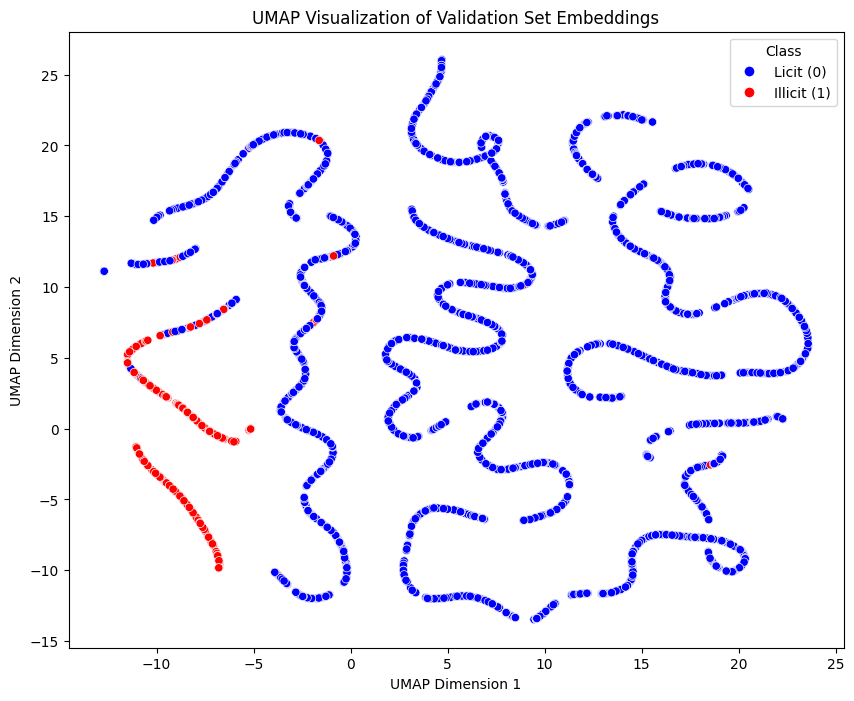

中间间隔时间: 14.64243483543396 秒


In [7]:
import pandas as pd
import numpy as np
import torch
import time
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.nn import GATv2Conv
from torch.nn import BatchNorm1d
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
from types import SimpleNamespace
import os
import copy
import warnings
import torch.nn as nn
from torch_geometric.nn.conv import MessagePassing
from torch_geometric.utils import add_self_loops
from torch.nn import GRUCell
warnings.filterwarnings('ignore')

# 加载数据
df_features = pd.read_csv('dataset/elliptic_txs_features.csv', header=None)
df_edges = pd.read_csv("dataset/elliptic_txs_edgelist.csv")
df_classes = pd.read_csv("dataset/elliptic_txs_classes.csv")

# 映射类别：licit=0, illicit=1, unknown=2
df_classes['class'] = df_classes['class'].map({'unknown': 2, '1': 1, '2': 0})

# 合并特征和类别
df_merge = df_features.merge(df_classes, how='left', right_on="txId", left_on=0)
df_merge = df_merge.sort_values(0).reset_index(drop=True)


# 配置
config = SimpleNamespace(
    seed=0,
    learning_rate=0.001,
    weight_decay=1e-5,
    input_dim=165,  # 特征维度（假设特征文件有165列特征，排除txId和时间步）
    output_dim=1,
    hidden_size=1024,
    num_epochs=10,
    checkpoints_dir='./models/elliptic_gnn',
    device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
)

class SAGEConv(MessagePassing):
    def __init__(self, in_channels, out_channels, n_dim):
        super().__init__(aggr='mean')  # 使用 mean 聚合
        self.lin = nn.Linear(in_channels + n_dim, out_channels)
        self.relu = nn.ReLU()

    def forward(self, x, x0, edge_index):
        # x 是节点自身的特征（用于更新），x0 是邻居节点的特征（用于聚合）
        # edge_index, _ = add_self_loops(edge_index, num_nodes=x.size(0))

        return self.propagate(edge_index, x=x, x0=x0)

    def message(self, x_j, x0_j):
        # 注意：这里我们只使用 x0_j 来传播邻居信息
        return x0_j

    def update(self, aggr_out, x):
        # x 是节点本身的特征，拼接后线性映射
        out = torch.cat([x, aggr_out], dim=1)
        return self.relu(self.lin(out))

class SAGEwithGRU(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, n_dim):
        super().__init__()
        self.atten = nn.Parameter(torch.randn(1, in_channels))
        self.norm1 = BatchNorm1d(in_channels)
        self.norm2 = BatchNorm1d(hidden_channels)
        self.sage_layer1 = SAGEConv(in_channels, hidden_channels, n_dim)
        self.sage_layer2 = SAGEConv(hidden_channels, hidden_channels, n_dim)
        self.gru = GRUCell(in_channels, hidden_channels)
        self.out = nn.Linear(hidden_channels, out_channels)
        self.dropout = nn.Dropout(p=0.2)

    def forward(self, x, edge_index, h):
        x0 = x * self.atten
        x = x * self.atten
        x = self.norm1(x)
        x = F.leaky_relu(x)
        # x = self.dropout(x)   # 加dropout
        x = self.sage_layer1(x, x0, edge_index)
        x = self.norm2(x)
        x = F.leaky_relu(x)
        # x = self.dropout(x)   # 加dropout
        x = self.sage_layer2(x, x0, edge_index)
        x0_mean = x0.mean(dim=0)
        x0_mean = x0_mean.unsqueeze(0)
        h = self.gru(x0_mean, h.detach())
        x = x + h
        x = self.out(x)
        return x, h

# 准确率计算（与原代码相同）
def accuracy(y_pred, y_test, epoch, prediction_threshold=0.5):
    y_pred_label = (torch.sigmoid(y_pred) > prediction_threshold).float()
    correct_results_sum = (y_pred_label == y_test).sum().float()
    acc = correct_results_sum / y_test.shape[0]
    
    if epoch % 10 == 0 :
        print(f'correct_results_sum:{correct_results_sum},all_sum:{y_test.shape[0]},err:{y_test.shape[0]-correct_results_sum}')
        
    return acc

# 测试函数（与原代码类似，适配子图）
def test(model, data):
    model.eval()
    with torch.no_grad():
        out = model(data.x, data.edge_index)
        preds = ((torch.sigmoid(out) > 0.5).float()).squeeze(1)
    return preds

# 按时间步分割数据并创建子图
def create_subgraphs(df_merge, df_edges):
    subgraphs = []
    for timestep in range(1, 50):  # 时间步从1到49
        # 筛选当前时间步的节点
        df_nodes_t = df_merge[df_merge[1] == timestep].copy()
        
        node_ids = df_nodes_t[0].values  # 当前时间步的交易ID
        
        # 筛选当前时间步的边
        df_edges_t = df_edges[df_edges['txId1'].isin(node_ids) & df_edges['txId2'].isin(node_ids)].copy()
        
        # 如果子图为空（没有节点或边），跳过
        if len(df_nodes_t) == 0 or len(df_edges_t) == 0:
            continue
        
        # 重新映射节点ID为0到N-1（N为当前子图节点数）
        map_id = {j: i for i, j in enumerate(node_ids)}
        df_nodes_t[0] = df_nodes_t[0].map(map_id)
        df_edges_t['txId1'] = df_edges_t['txId1'].map(map_id)
        df_edges_t['txId2'] = df_edges_t['txId2'].map(map_id)
        
        # 构造边索引
        edge_index = np.array(df_edges_t[['txId1', 'txId2']].values).T
        edge_index = torch.tensor(edge_index, dtype=torch.long).contiguous()
        
        # 提取节点特征（排除txId、时间步和类别）
        node_features = df_nodes_t.drop([0, 1, 'txId', 'class'], axis=1).values
        node_features = torch.tensor(node_features, dtype=torch.float32)
        
        # 提取标签
        labels = df_nodes_t['class'].values
        labels = torch.tensor(labels, dtype=torch.float32)
        
        # 筛选已知标签的节点（class != 2）
        classified_idx = df_nodes_t.index[df_nodes_t['class'] != 2].values
        classified_idx = torch.tensor([map_id[df_merge.loc[i, 0]] for i in classified_idx], dtype=torch.long)
        
        # 构造Data对象
        data = Data(
            x=node_features,
            x0=node_features,
            edge_index=edge_index,
            y=labels
        )
        
        # 分割训练和验证集
        if len(classified_idx) > 0:
            _, _, _, _, train_idx, val_idx = train_test_split(
                node_features[classified_idx],
                labels[classified_idx],
                classified_idx,
                test_size=0.15,
                random_state=config.seed,
                stratify=labels[classified_idx]
            )
            data.train_idx = torch.tensor(train_idx, dtype=torch.long)
            data.val_idx = torch.tensor(val_idx, dtype=torch.long)
        
        subgraphs.append(data)
        
        print(f'subgraphs0{timestep}Done')
    
    return subgraphs

# 在文件开头添加UMAP导入
import umap
from matplotlib.lines import Line2D
# 修改 train_evaluate_subgraphs 函数
def train_evaluate_subgraphs(model, subgraphs, criterion, optimizer, config):
    best_val_acc = 0.0
    best_model = copy.deepcopy(model.state_dict())
    h = torch.zeros(1, config.hidden_size)
    h = h.to(config.device)
    test_all_preds = []
    test_all_labels = []
    
    for epoch in range(config.num_epochs + 1):
        model.train()
        all_train_out = []  # 存储所有子图的训练预测
        all_train_labels = []  # 存储所有子图的训练标签
        all_val_out = []  # 存储所有子图的验证预测
        all_val_labels = []  # 存储所有子图的验证标签
        total_train_loss = 0.0
        total_val_loss = 0.0
        num_train_samples = 0
        num_val_samples = 0
        
        # 遍历所有子图
        for t, data in enumerate(subgraphs):
            if not hasattr(data, 'train_idx') or len(data.train_idx) == 0:
                print(f"Skipping timestep {t+1}: No labeled data for training")
                continue
            
            data = data.to(config.device)
            optimizer.zero_grad()
            out, h = model(data.x, data.edge_index, h)
            
            # 计算训练损失并更新模型
            train_loss = criterion(out[data.train_idx], data.y[data.train_idx].unsqueeze(1))
            train_loss.backward()
            optimizer.step()
            
            # 收集训练预测和标签
            all_train_out.append(out[data.train_idx].detach())
            all_train_labels.append(data.y[data.train_idx].unsqueeze(1))
            total_train_loss += train_loss.item() * len(data.train_idx)
            num_train_samples += len(data.train_idx)
            
            # 收集验证预测和标签
            val_loss = criterion(out[data.val_idx], data.y[data.val_idx].unsqueeze(1))
            all_val_out.append(out[data.val_idx].detach())
            all_val_labels.append(data.y[data.val_idx].unsqueeze(1))
            total_val_loss += val_loss.item() * len(data.val_idx)
            num_val_samples += len(data.val_idx)
        
        # 计算训练损失和准确率
        all_train_out = torch.cat(all_train_out)
        all_train_labels = torch.cat(all_train_labels)
        avg_train_loss = total_train_loss / num_train_samples
        train_acc = accuracy(all_train_out, all_train_labels, epoch=1)
        
        # 计算验证损失和准确率
        avg_val_loss = total_val_loss / num_val_samples if num_val_samples > 0 else float('inf')
        val_acc = accuracy(torch.cat(all_val_out), torch.cat(all_val_labels), epoch) if all_val_out else 0.0
        
        # 每10个epoch打印一次
        if epoch % 10 == 0:
            print(f'Epoch {epoch:>3} | Train Loss: {avg_train_loss:.3f} | Train Acc: '
                  f'{train_acc*100:>6.2f}% | Val Loss: {avg_val_loss:.4f} | '
                  f'Val Acc: {val_acc*100:.2f}%')
        
        # 保存最佳模型（基于验证准确率）
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            test_all_preds = torch.cat(all_val_out).cpu()
            test_all_labels = torch.cat(all_val_labels).cpu()
            best_model = copy.deepcopy(model.state_dict())
    
    # 保存最佳模型
    # torch.save(best_model, 'sage-gru-all-49.pth')
    
    # 计算最终准确率
    y_pred = test_all_preds
    y_test = test_all_labels
    y_pred_label = (torch.sigmoid(y_pred) > 0.5).float()
    correct_results_sum = (y_pred_label == y_test).sum().float()
    print(f'correct_results_sum:{correct_results_sum},all_sum:{y_test.shape[0]},err:{y_test.shape[0]-correct_results_sum}')
    
    # UMAP可视化
    model.load_state_dict(best_model)  # 加载最佳模型
    model.eval()
    
    # 提取所有子图的验证集嵌入
    all_val_embeddings = []
    all_val_labels = []
    h = torch.zeros(1, config.hidden_size).to(config.device)
    
    with torch.no_grad():
        for data in subgraphs:
            if not hasattr(data, 'val_idx') or len(data.val_idx) == 0:
                continue
            data = data.to(config.device)
            out, h = model(data.x, data.edge_index, h)
            all_val_embeddings.append(out[data.val_idx].cpu())
            all_val_labels.append(data.y[data.val_idx].cpu())
    
    # 拼接所有验证集嵌入和标签
    all_val_embeddings = test_all_preds.numpy()
    all_val_labels = torch.cat(all_val_labels).numpy()
    
    # 应用UMAP降维
    reducer = umap.UMAP(n_components=2, random_state=config.seed)
    embedding = reducer.fit_transform(all_val_embeddings)
    
    # 可视化
    plt.figure(figsize=(10, 8))
    sns.scatterplot(
        x=embedding[:, 0], 
        y=embedding[:, 1], 
        hue=all_val_labels, 
        palette={0: 'blue', 1: 'red'}, 
        style=all_val_labels, 
        markers={0: 'o', 1: 'o'},
        legend='full'
    )
    plt.title('UMAP Visualization of Validation Set Embeddings')
    plt.xlabel('UMAP Dimension 1')
    plt.ylabel('UMAP Dimension 2')
    
    legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='Licit (0)',
           markerfacecolor='blue', markersize=8),
    Line2D([0], [0], marker='o', color='w', label='Illicit (1)',
           markerfacecolor='red', markersize=8)
    ]
    plt.legend(handles=legend_elements, title='Class')
    
    plt.savefig('umap_visualization.jpg',dpi=300, bbox_inches='tight')
    plt.show()
    

# 主程序
torch.manual_seed(config.seed)

# 创建子图
file_path = 'subgraphs0.pt'

if os.path.exists(file_path):
    print(" 子图已存在，可以直接加载。")
    subgraphs = torch.load(file_path)
else:
    subgraphs = create_subgraphs(df_merge, df_edges)
    torch.save(subgraphs, 'subgraphs0.pt')
    
print(f"Created {len(subgraphs)} subgraphs0")

# 初始化模型、优化器和损失函数
model = SAGEwithGRU(config.input_dim, config.hidden_size, config.output_dim, config.input_dim).to(config.device)
optimizer = torch.optim.Adam(model.parameters(), lr=config.learning_rate, weight_decay=config.weight_decay)
criterion = torch.nn.BCEWithLogitsLoss()

# 训练和评估
start_time = time.time()
train_evaluate_subgraphs(model, subgraphs, criterion, optimizer, config)
end_time = time.time()
interval = end_time - start_time
print("中间间隔时间:", interval, "秒")

In [6]:
import umap
reducer = umap.UMAP(n_components=2, random_state=42)

In [7]:
import umap
print(umap.__file__)        # 看看加载的是哪个文件
print(umap.__version__)     # 检查版本

/root/miniconda3/lib/python3.10/site-packages/umap/__init__.py


AttributeError: module 'umap' has no attribute '__version__'

In [8]:
import umap
print(umap.__file__)

/root/miniconda3/lib/python3.10/site-packages/umap/__init__.py


In [9]:
import umap
print(umap.__file__)
print(dir(umap))  # 应该看到有 'UMAP

/root/miniconda3/lib/python3.10/site-packages/umap/__init__.py
['__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__path__', '__spec__']


In [10]:
from umap import UMAP

reducer = UMAP(n_components=2, random_state=42)

ImportError: cannot import name 'UMAP' from 'umap' (/root/miniconda3/lib/python3.10/site-packages/umap/__init__.py)

In [11]:
import importlib.metadata
print(importlib.metadata.version("umap-learn"))

0.5.7
